# 查看语料

In [1]:
words = open("names.txt", 'r').read().splitlines()
len(words)

32033

In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
min(len(w) for w in words), max(len(w) for w in words), sum(len(w) for w in words)/len(words)

(2, 15, 6.122217712983486)

# Bigram

对于字符级别的语言模型来说, `Bigram`意味着每次只处理两个字符（而不是word级别是两个分词）
+ 即每次只给定一个字符，然后预测下一个字符 → 总是根据前一个(previous)字符预测下一个(next)字符
+ 相当于只对局部结构建模（也可以理解为: 建模的窗口只有2个字符）, 会导致忽略掉很多其他信息

In [4]:
for w in words[:3]:
    chs = ['<S>'] + list(w) + ['<E>'] 
    # 添加首尾
    for ch1, ch2 in zip(chs, chs[1:]):
        # 这里的遍历, 只要有一个列表到头了,整个遍历过程就停止了
        print(ch1,ch2)

<S> e
e m
m m
m a
a <E>
<S> o
o l
l i
i v
v i
i a
a <E>
<S> a
a v
v a
a <E>


构建一种字典结构，来统计每个bigram对出现的次数

In [5]:
b = {}
for w in words[:3]:
    chs = ['<S>'] + list(w) + ['<E>'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram, 0) + 1
        # print(ch1,ch2)
b

{('<S>', 'e'): 1,
 ('e', 'm'): 1,
 ('m', 'm'): 1,
 ('m', 'a'): 1,
 ('a', '<E>'): 3,
 ('<S>', 'o'): 1,
 ('o', 'l'): 1,
 ('l', 'i'): 1,
 ('i', 'v'): 1,
 ('v', 'i'): 1,
 ('i', 'a'): 1,
 ('<S>', 'a'): 1,
 ('a', 'v'): 1,
 ('v', 'a'): 1}

In [6]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [7]:
sorted_b = sorted(b.items(), key = lambda kv:kv[1])  # 按照值排序, 默认升序
sorted_b[0], sorted_b[-1]

((('q', 'r'), 1), (('n', '<E>'), 6763))

将这些bigram的出现次数放在二维数组中会更方便，
+ 比如：用行(row)表示bigram的第一个字符，用列(column)表示bigram的第二个字符
+ 这里也很好操作，对于字符级来说(这个语料只涉及26个字母 + 2个起始标志字符)，因此也就是一个 28行，28列的矩阵，直接每个字符映射一个整数，作为行号/列号即可
+ 计算也可以发现，上面只有627种组合，小于 28*28的组合，即：有些组合是不存在的，直接统计次数设置为0即可

只是因为这个语料比较简单，如果是更常规的英文自然语料，至少得是 ASCII 127个字符，那么矩阵就变成了 129*129了

如果是纯中文，就得变成6800左右的一个方阵了

In [8]:
len(b), (26+2)*(26+2)

(627, 784)

In [9]:
import torch
a= torch.zeros([3,5])
print(a, a.dtype)
# torch创建tensor的时候 默认是单精度浮点数，这里需要表示次数，因此，需要改成 torch.int32
a= torch.zeros([3,5], dtype=torch.int32)
print(a, a.dtype)

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]]) torch.float32
tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32) torch.int32


In [10]:
for i,num in enumerate(['a', 'b', 'c']):
    print(i, num)

0 a
1 b
2 c


## 带有冗余的辞典(首尾两个字符)

In [11]:
# 为了能够把字符/单词表示成整数， 这里需要构建 字符到整数的映射字典，以及整数到字符的映射字典
chars = sorted(list(set(''.join(words))))
print(chars[:3],len(chars))

# string/character to index
stoi = {s:i for i,s in enumerate(chars)}
stoi['<S>'] = 26
stoi['<E>'] = 27

itos = {i:s for s,i in stoi.items()}
# itos = {i:s for i,s in enumerate(chars)}
# itos[26] = '<S>'
# itos[27] = '<E>'
print(stoi["a"])
print(itos[0])

['a', 'b', 'c'] 26
0
a


In [12]:
N = torch.zeros([28,28], dtype=torch.int32)
for w in words:
    chs = ['<S>'] + list(w) + ['<E>'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        row = stoi[ch1]
        col = stoi[ch2]
        N[row,col]+=1

上面在统计 字典b的 次数的时候，有 ： `((('q', 'r'), 1), (('n', '<E>'), 6763))`， 这里验证下

In [13]:
row = stoi['n']
col = stoi['<E>']
N[row,col]

tensor(6763, dtype=torch.int32)

(-0.5, 27.5, 27.5, -0.5)

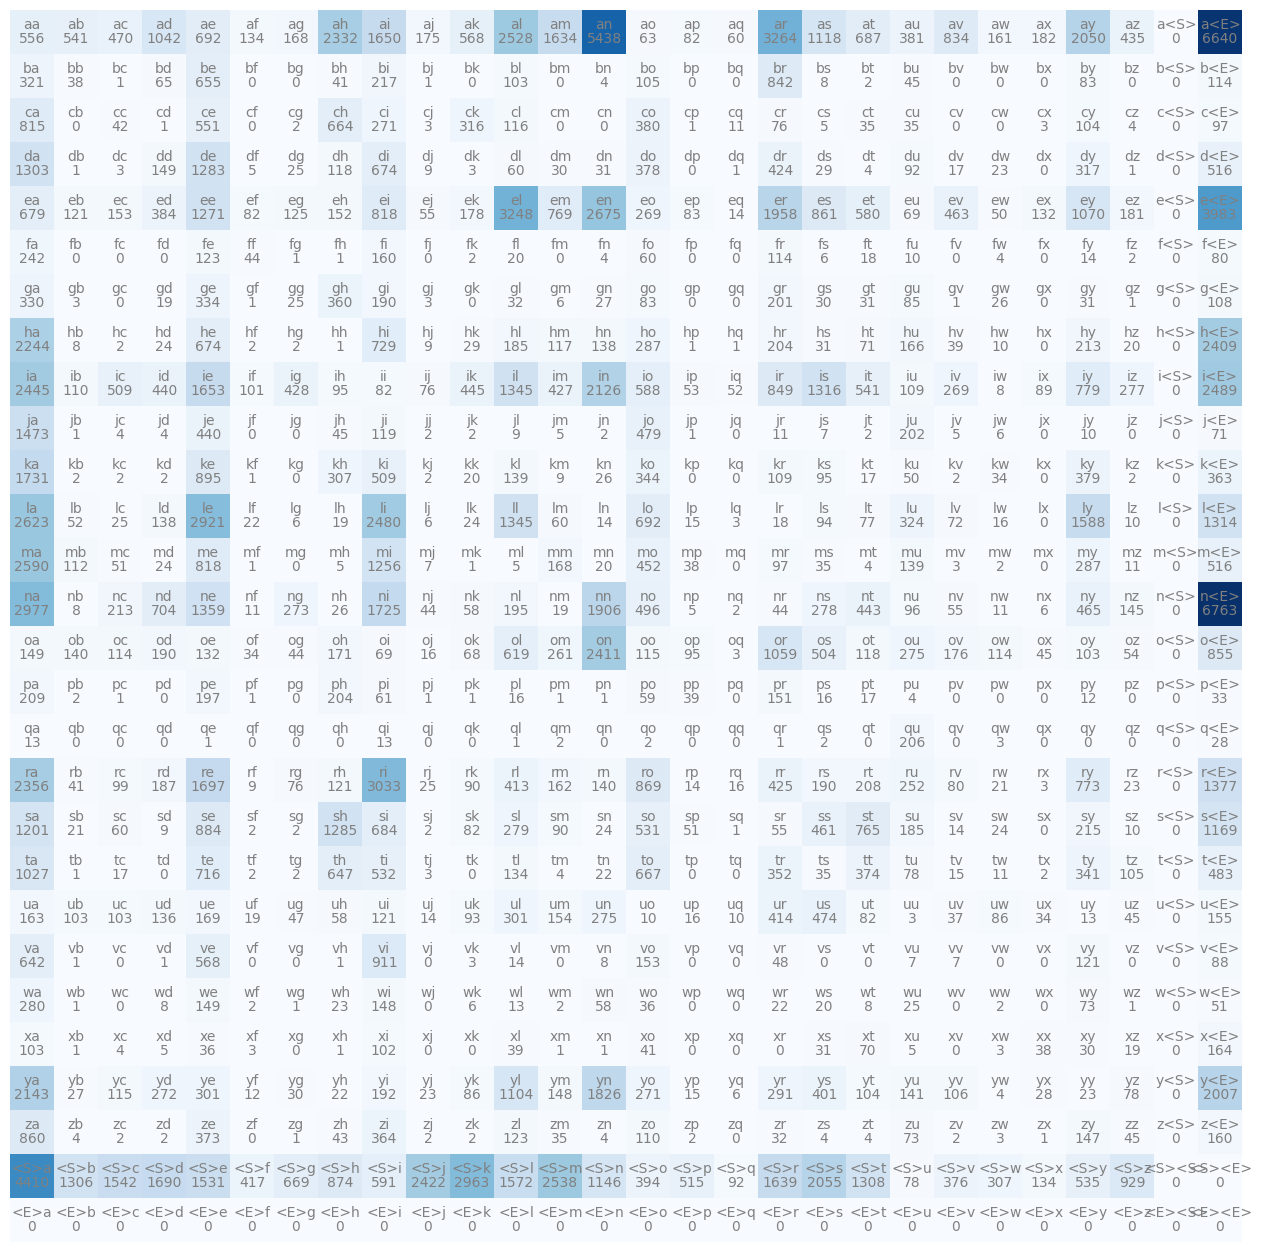

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline
# plt.imshow(N)  # 这样直接显示会很丑

plt.figure(figsize=(16,16))
plt.imshow(N, cmap = 'Blues')
for i in range(28):
    for j in range(28):
        chstr = itos[i]+itos[j]
        plt.text(j, i, chstr, ha = 'center', va = 'bottom', color = 'gray')
        plt.text(j, i, N[i,j].item(), ha = 'center', va = 'top', color = 'gray')
        # 如果是 plt.text(i,j,xxx)
        # 则第一行显示的是 aa,ba,ca,da
        #  第一列显示的是  aa,ab,ac,ad
        # 这里写成 j,i的原因是 j表示x轴，同时j是内循环，i表示y轴，i是外循环
        # 所以先i，第x行， 然后所有的j，第x列
plt.axis('off')

# 这里可以看到， plt.text(x: 'float',y: 'float'） 所以这里用j作为横坐标，i作为纵坐标，显示的是 N[i,j]和chstr 
# 不用特别在意matplotlib行列和 numpy行列相反这个问题
# 同理 在这里可以看到 n<E> 是6763 <E>在n后面的情况是出现了 6763次

从上图中可以看出：
+ 对于最后一行，`<E>`永远不会作为第一个字符出现
+ 对于导数第二列，`<S>`永远不会作为第二个字符出现
+ 因此，出现了一个整行和一个整列的0值
+ 同时倒数第二行，`<S>`开头的这行，出现了 `<S><E>`次数为0，也不会出现空字符的情况
+ 因此这些值是没有必要存储的，永远不会出现这种字符组合的情况

以前用pandas绘图的：[动手学深度学习V2.0(Pytorch)——23. LeNet（mnist）->2.1 灰度图显示mnist数字](https://stitch.blog.csdn.net/article/details/121845440)

In [15]:
import pandas as pd
df = pd.DataFrame(N)
df.columns = df.columns.map(itos)
df.index = df.index.map(itos)
df.style.set_properties(**{'font-size':'4pt'}).background_gradient('Greys')

,a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t,u,v,w,x,y,z,,
a,556,541,470,1042,692,134,168,2332,1650,175,568,2528,1634,5438,63,82,60,3264,1118,687,381,834,161,182,2050,435,0,6640
b,321,38,1,65,655,0,0,41,217,1,0,103,0,4,105,0,0,842,8,2,45,0,0,0,83,0,0,114
c,815,0,42,1,551,0,2,664,271,3,316,116,0,0,380,1,11,76,5,35,35,0,0,3,104,4,0,97
d,1303,1,3,149,1283,5,25,118,674,9,3,60,30,31,378,0,1,424,29,4,92,17,23,0,317,1,0,516
e,679,121,153,384,1271,82,125,152,818,55,178,3248,769,2675,269,83,14,1958,861,580,69,463,50,132,1070,181,0,3983
f,242,0,0,0,123,44,1,1,160,0,2,20,0,4,60,0,0,114,6,18,10,0,4,0,14,2,0,80
g,330,3,0,19,334,1,25,360,190,3,0,32,6,27,83,0,0,201,30,31,85,1,26,0,31,1,0,108
h,2244,8,2,24,674,2,2,1,729,9,29,185,117,138,287,1,1,204,31,71,166,39,10,0,213,20,0,2409
i,2445,110,509,440,1653,101,428,95,82,76,445,1345,427,2126,588,53,52,849,1316,541,109,269,8,89,779,277,0,2489
j,1473,1,4,4,440,0,0,45,119,2,2,9,5,2,479,1,0,11,7,2,202,5,6,0,10,0,0,71


## 不带冗余的辞典(首尾一个字符)

In [16]:
import torch
N = torch.zeros([27,27], dtype=torch.int32)

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}  # 有意义的这些字符的index就从1开始
stoi['.'] = 0  # 这里用 . 代替之前的<S><E>,同时设置这个字符的index是0

itos = {i:s for s,i in stoi.items()}

In [17]:
for w in words:
    chs = ['.'] + list(w) + ['.'] 
    # 这里其实有点 BPE 的感觉， 就是标点符号归前面的字符还是归后面的字符
    # 这里很明显，如果 . 首先出现，就是首位；如果其他字符出现，那之后出现的.就是末尾
    # 依靠与其他字符的相对位置关系，就可以判断这个 . 是首还是尾
    for ch1, ch2 in zip(chs, chs[1:]):
        row = stoi[ch1]
        col = stoi[ch2]
        N[row,col]+=1

(-0.5, 26.5, 26.5, -0.5)

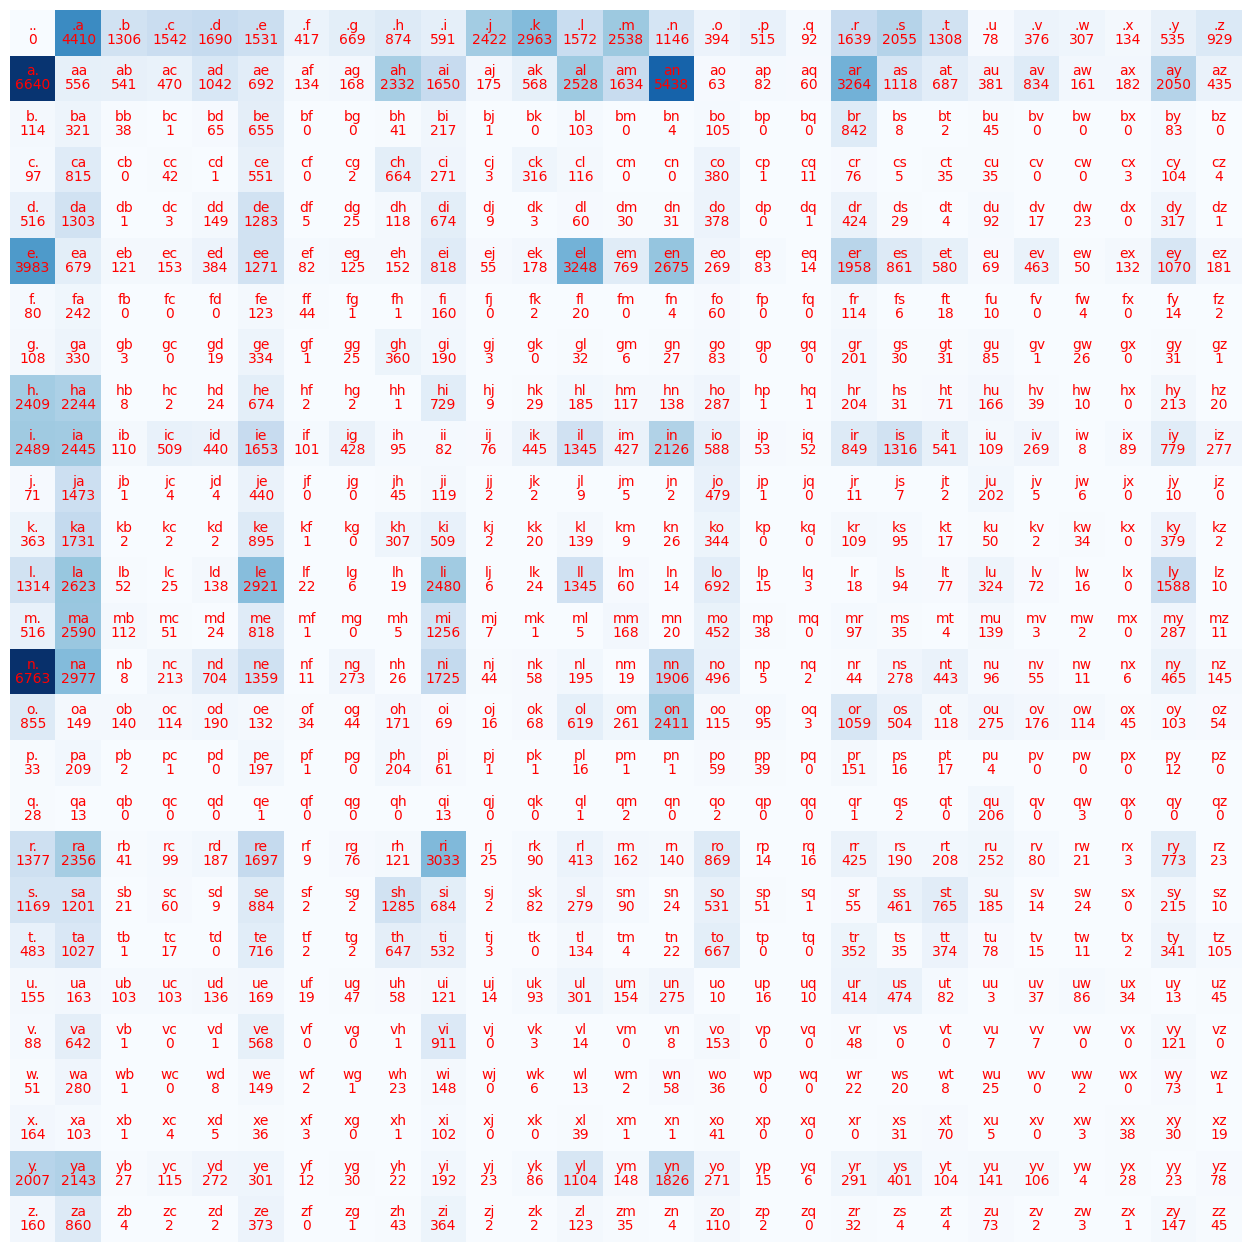

In [18]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap = 'Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i]+itos[j]
        plt.text(j, i, chstr, ha = 'center', va = 'bottom', color = 'red')
        plt.text(j, i, N[i,j].item(), ha = 'center', va = 'top', color = 'red')
plt.axis('off')

左上角第一个表示 `..`这个情况出现的次数为0

由于这里 `.` 的index是0，所以 之前的 出现在最后一列的`n<E>=6763`,现在出现在 n所在行的第一列了，`.n=6763` 

同时用`.`作为index 0，上图可以清晰的看出：
1. 第一行其实是`a,b,...,z`作为首个字符出现的次数
2. 第一列其实是`a,b,...,z`作为最后一个字符出现的次数
3. 中间其他就是和其他字符组合出现的次数，在首和尾之间出现的情况

In [19]:
# N[0]  # 等价于 N[0,:]
p = N[0].float()  # 转为浮点数，准备归一化为概率
p = p/sum(p)
p, p.sum()

(tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
         0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
         0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290]),
 tensor(1.))

为了从p的概率分布中采样，可以使用
+ torch的multinomial函数（就是根据输入，然后用输入的值来作为采样的权重，返回采样的样本的索引），[torch.multinomial](https://docs.pytorch.org/docs/2.12/generated/torch.multinomial.html)
+ 同时，为了保证采样结果的一致性，这里可以通过控制生成器的种子设置来实现这一效果：[Generator](https://docs.pytorch.org/docs/2.12/generated/torch.Generator.html)

In [20]:
g = torch.Generator().manual_seed(2147483647)
# 是一种创建pytorch生成器对象的确定性方法，即：只要用了这段代码，不管是其他机器或者其他环境，结果都是一致可复现的
p = torch.rand(3, generator = g)
p = p/p.sum()
p  # 验证了，确实和老师显示的一致

tensor([0.6064, 0.3033, 0.0903])

In [21]:
# replacement = True,表示有放回采样（即：采样之后会放回去，下次采样依然有概率采到），我们这里设置是True，但是这个值默认是False，即：不放回采样
torch.multinomial(p, num_samples = 20, replacement = True, generator = g)
# 运行后发现，确实和老师的采样结果都一毛一样

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1])

这里的 `p=tensor([0.6064, 0.3033, 0.0903])`

即： 
+ index = 0 的这个数有60%的概率会被采到，20次的话， 会出现12次
+ index = 1 的这个数有30%的概率会被采到，20次/6次
+ index = 2 的这个数有10%的概率会被采到，20次/2次

和上面出现的采样结果一致

采样次数越多，采样结果的数字分布就越接近于这里的概率分布

## 手动采样过程

In [22]:
p = N[0].float()  # 转为浮点数，准备归一化为概率
p = p/p.sum()
print(p)
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item() # 出来的是个列表格式
ix, itos[ix]

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])


(10, 'j')

很尴尬， p的概率值一样， 但是采样出来索引不一样。。。老师是13，对应m；我是10，对应j

In [23]:
p = N[10].float()
p = p/p.sum()
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item() # 出来的是个列表格式
ix, itos[ix]

(1, 'a')

## 循环采样

这里可以知道,整体的采样流程其实就是:
1. 从索引0开始, 因为 index = 0 → `.` 是起始标记
2. 然后就开始从对应的 index对应的行 开始采样, 基于采样结果继续 锁定下一个行,继续采样
3. 直到采样到 `.`停止标记, 就停止采样

In [24]:
g = torch.Generator().manual_seed(2147483647)
ix = 0
result = ''
while True:
    p = N[ix].float()
    p = p/p.sum()
    ix = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item() 
    print(itos[ix])
    result+=itos[ix]
    if ix==0:
        break
print(f'最终的采样结果为: {result}')    

j
u
n
i
d
e
.
最终的采样结果为: junide.


In [25]:
for i in range(10):
    ix = 0
    result = ''
    while True:
        p = N[ix].float()
        p = p/p.sum()
        ix = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item() 
        result+=itos[ix]
        if ix==0:
            break
    print(f'最终的采样结果为: {result}')  

最终的采样结果为: janasah.
最终的采样结果为: p.
最终的采样结果为: cony.
最终的采样结果为: a.
最终的采样结果为: nn.
最终的采样结果为: kohin.
最终的采样结果为: tolian.
最终的采样结果为: juee.
最终的采样结果为: ksahnaauranilevias.
最终的采样结果为: dedainrwieta.


这里的 `p.`, `a.`

从模型的角度来说, 它并不清楚这个名字是`p`开头的, 因为是以`.`启动的,同时窗口只有2

但是`p`作为最后一个字符出现的概率并不低(出现了33次, `a.`出现了6000多次), 因此会出现这种情况

所以基于Bigram生成的名字看起来会有点像随机生成的感觉,根本看不出来是人名

In [26]:
for i in range(10):
    ix = 0
    result = ''
    while True:
        p = torch.ones(27)/27.0 # 看一下均匀分布的结果,即直接全部随机生成
        ix = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item() 
        result+=itos[ix]
        if ix==0:
            break
    print(f'最终的采样结果为: {result}')  

最终的采样结果为: snjyievyvaftbzffvmumthyfodtumjrpfytszwjhrjagq.
最终的采样结果为: coreaysezocfkyjjabdywejfmoifmwyfinwagaasnhsvfihofszxhddgosfmptpagicz.
最终的采样结果为: rjpiufmthdt.
最终的采样结果为: rkrrsru.
最终的采样结果为: iyumuyfy.
最终的采样结果为: mjekujcbkhvupwyhvpvhvccragr.
最终的采样结果为: wdkhwfdztta.
最终的采样结果为: mplyisbxlyhuuiqzavmpocbzthqmimvyqwat.
最终的采样结果为: f.
最终的采样结果为: .


>由此至少可以知道:
>
>Bigram的效果, 肯定比随机生成的要好, 这些先验的出现次数/频率, 还是发挥了一些作用的

## P计算优化

In [27]:
# 上面代码有点冗余,改掉
P = N.float()
# P = torch.div(N, N.sum(dim = 1, keepdim = True))
P = N/ N.sum(dim = 1, keepdim = True)
# 注意,这里是一行里所有的加起来,所以是列方向的求和

# N.sum(dim = 1, keepdim = True) 从 N的(27,27)变成了(27,1)的形状
# 这里dim=0和dim=1的求和结果一样, 是因为bigram本身是个对称矩阵,
# P[0]  # 验证一下,和上面结果一样

[torch.sum](https://docs.pytorch.org/docs/2.12/generated/torch.sum.html)

[torch.div](https://docs.pytorch.org/docs/2.12/generated/torch.div.html#torch.div)

In [28]:
print(N.sum(dim = 1, keepdim = True).shape,  N.shape)
P = N/N.sum(dim = 1, keepdim = True)
print(P[0])

torch.Size([27, 1]) torch.Size([27, 27])
tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])


[27,27]/[27,1]   这里操作后，得到的就是 [27,27]   

[27,1] 是个列向量   [1,27]是个行向量

In [29]:
print(N.sum(dim = 1).shape,  N.shape)
P = N/N.sum(dim = 1)
print(P[0])

torch.Size([27]) torch.Size([27, 27])
tensor([0.0000, 0.1301, 0.4938, 0.4366, 0.3075, 0.0750, 0.4608, 0.3472, 0.1148,
        0.0334, 0.8352, 0.5879, 0.1126, 0.3821, 0.0625, 0.0497, 0.5019, 0.3382,
        0.1291, 0.2535, 0.2348, 0.0249, 0.1461, 0.3305, 0.1923, 0.0547, 0.3874])


torch.Size([27])  torch.Size([27, 27]) 此时也依然支持广播

这里在计算的时候，会先把 [27] → [1,27], 计算的时候扩展/复制的是第一个维度

但是我们希望的计算，是发生在第二个维度上的，所以就不大对了

上面的问题来自于，广播机制计算时，维度尺寸是从右向左的，导致添加的维度改变了原始的行列对应

In [30]:
P = N.float()
# P = P/P.sum(dim = 1, keepdim = True) # 这样写会创建一个全新的向量 然后再赋值给p
# 可以直接使用原地操作，这样执行起来会更快
P/=P.sum(dim = 1, keepdim = True)
g = torch.Generator().manual_seed(2147483647)
for i in range(10):
    ix = 0
    result = ''
    while True:
        ix = torch.multinomial(P[ix], num_samples = 1, replacement = True, generator = g).item() 
        result+=itos[ix]
        if ix==0:
            break
    print(f'最终的采样结果为: {result}')  

最终的采样结果为: junide.
最终的采样结果为: janasah.
最终的采样结果为: p.
最终的采样结果为: cony.
最终的采样结果为: a.
最终的采样结果为: nn.
最终的采样结果为: kohin.
最终的采样结果为: tolian.
最终的采样结果为: juee.
最终的采样结果为: ksahnaauranilevias.


> 上面的 N（P）矩阵其实就是模型参数了

## 评测模型效果/性能

In [31]:
for w in words[:3]:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        row = stoi[ch1]
        col = stoi[ch2]
        prob = P[row,col]
        print(f"{ch1}{ch2}: {prob:.4f}")

.e: 0.0478
em: 0.0377
mm: 0.0253
ma: 0.3899
a.: 0.1960
.o: 0.0123
ol: 0.0780
li: 0.1777
iv: 0.0152
vi: 0.3541
ia: 0.1381
a.: 0.1960
.a: 0.1377
av: 0.0246
va: 0.2495
a.: 0.1960


In [32]:
1/27

0.037037037037037035

对于27个字符来说，如果每个字符是相同概率出现，那么每个字符出现的概率是 4%左右， 

高于这个概率的就可以认为：从数据集的二元组次数统计里学到了一些东西

可以看到，上面有 `ma = 38%, a.=19%`等

问题：**如何把上面这些概率汇总成一个数字，用来描述模型的性能**

[wiki-Maximum likelihood estimation](https://en.wikipedia.org/wiki/Maximum_likelihood_estimation)
+ 似然是上面所有概率的乘积
+ 这个**似然（所有概率的乘积）， 反映的就是 训练的模型 赋予 整个训练数据集 的概率**
+ 似然，就可以作为衡量模型性能的一个指标
+ 这个似然，就很像困惑度指标了： [深入理解语言模型的困惑度(perplexity)](https://zhuanlan.zhihu.com/p/686808564)

因此，希望在模型的训练过程中，这些概率的乘积要尽可能的高

在上面的例子中，概率都是小数，所以连乘之后，肯定是个远远小于1的很小的小数
+ 因此，一般不直接使用似然(`likelihood`)，而是使用 对数似然(`log likelihood`)
+ `log(a*b*c) = loga + logb + logc`, 即:log乘法=log加法
+ 但是由于log函数得到的值的范围是 -∞,0, 而我们**希望损失函数越小越好,因此,需要使用负似然对数**
    + 负似然对数是一个非常理想的损失函数,最大值是0
    + 值越大,说明效果越差; 值越小,说明效果越好
    + 通常,还会根据样本个数来进行归一化, 即**平均负似然对数**
+ 也可以直接访问:[wolframalpha](https://www.wolframalpha.com/input?i=log%28x%29+from+0+to+1&lang=zh)网站,输入:`log(x) from 0 to 1`查看函数曲线

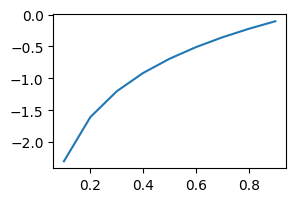

In [33]:
import numpy as np
x = np.arange(0.1,1,0.1)
y = np.log(x)
plt.figure(figsize=(3,2))
plt.plot(x,y)

In [34]:
log_likelihood = 0
n = 0
for w in words[:3]:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        row = stoi[ch1]
        col = stoi[ch2]
        prob = P[row,col]
        log_prob = torch.log(prob)
        log_likelihood+=log_prob
        n+=1
        print(f"{ch1}{ch2}: {prob:.4f}, log_prob: {log_prob:.4f}")
print(f"log_likelihood: {log_likelihood}")
# negative log-likelihood
nll = -log_likelihood/n
print(f"{nll=}")

.e: 0.0478, log_prob: -3.0408
em: 0.0377, log_prob: -3.2793
mm: 0.0253, log_prob: -3.6772
ma: 0.3899, log_prob: -0.9418
a.: 0.1960, log_prob: -1.6299
.o: 0.0123, log_prob: -4.3982
ol: 0.0780, log_prob: -2.5508
li: 0.1777, log_prob: -1.7278
iv: 0.0152, log_prob: -4.1867
vi: 0.3541, log_prob: -1.0383
ia: 0.1381, log_prob: -1.9796
a.: 0.1960, log_prob: -1.6299
.a: 0.1377, log_prob: -1.9829
av: 0.0246, log_prob: -3.7045
va: 0.2495, log_prob: -1.3882
a.: 0.1960, log_prob: -1.6299
log_likelihood: -38.78563690185547
nll=tensor(2.4241)


In [35]:
log_likelihood = 0
n = 0
for w in words:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        row = stoi[ch1]
        col = stoi[ch2]
        prob = P[row,col]
        log_prob = torch.log(prob)
        log_likelihood+=log_prob
        n+=1
nll = -log_likelihood/n
print(f"{nll=}")

nll=tensor(2.4541)


**至此,可以认为当前这个Bigram模型,对这个数据集的损失是 2.4, 这个数值就代表了模型的质量**

对于神经网络来说(上面的Bigram只是个例子, Bigram的模型参数是一个显示存储的P矩阵,但是神经网络就是通过计算得到的概率,不是显示存储的)
+ 目标: 最大化模型参数对应的数据的似然
    + `G0AL: maximize likelihood of the data w,r.t, model parameters (statistical modeling)`
+ `equivalent to maximizing the log likelihood (because log is monotonic)`
+ `equivalent to minimizing the negative log likelihood`
+ `equivalent to minimizing the average negative log likelihood`
+ `log(a*b*c)= log(a)+ log(b)+ log(c)`

## 模型平滑(虚拟计数)

In [36]:
log_likelihood = 0
n = 0
for w in ["andrejq"]:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        row = stoi[ch1]
        col = stoi[ch2]
        prob = P[row,col]
        log_prob = torch.log(prob)
        log_likelihood+=log_prob
        n+=1
        print(f"{ch1}{ch2}: {prob:.4f}, log_prob: {log_prob:.4f}")

nll = -log_likelihood/n
print(f"{nll=}")

.a: 0.1377, log_prob: -1.9829
an: 0.1605, log_prob: -1.8296
nd: 0.0384, log_prob: -3.2594
dr: 0.0771, log_prob: -2.5620
re: 0.1336, log_prob: -2.0127
ej: 0.0027, log_prob: -5.9171
jq: 0.0000, log_prob: -inf
q.: 0.1029, log_prob: -2.2736
nll=tensor(inf)


这里可以看到, 由于数据集中没有出现过`jq`这个组合,因此, 其log结果为负无穷,导致整个结果为负无穷

为了解决这种异常情况, 一般会选择一种非常简单的修正方法, 让模型更加平滑一些(**model smoothing**)

概括来说 就是会添加一些**虚拟计数**(fake counts): 
+ 例如: `对之前的统计次数,全部加1(这样就不会发生: 出现次数为0的情况)`
+ 也可以全部加5, 这样模型会更加平滑; 添加的虚拟计数越多, 模型就会越平滑(越失真)

In [37]:
P = (N + 1).float()
P/=P.sum(dim = 1, keepdim = True)
g = torch.Generator().manual_seed(2147483647)

log_likelihood = 0
n = 0
for w in ["andrejq"]:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        row = stoi[ch1]
        col = stoi[ch2]
        prob = P[row,col]
        log_prob = torch.log(prob)
        log_likelihood+=log_prob
        n+=1
        print(f"{ch1}{ch2}: {prob:.4f}, log_prob: {log_prob:.4f}")

nll = -log_likelihood/n
print(f"{nll=}")

.a: 0.1376, log_prob: -1.9835
an: 0.1604, log_prob: -1.8302
nd: 0.0384, log_prob: -3.2594
dr: 0.0770, log_prob: -2.5646
re: 0.1334, log_prob: -2.0143
ej: 0.0027, log_prob: -5.9004
jq: 0.0003, log_prob: -7.9817
q.: 0.0970, log_prob: -2.3331
nll=tensor(3.4834)


添加虚拟计数后, 就不会有无穷大的损失的情况了.

但是会导致推理有所不同

这里虚拟计数为1的时候, 看不出区别, 改成10的时候,就能看到明显区别了

In [38]:
P = (N+10).float()
P/=P.sum(dim = 1, keepdim = True)
g = torch.Generator().manual_seed(2147483647)
for i in range(10):
    ix = 0
    result = ''
    while True:
        ix = torch.multinomial(P[ix], num_samples = 1, replacement = True, generator = g).item() 
        result+=itos[ix]
        if ix==0:
            break
    print(f'最终的采样结果为: {result}')  

最终的采样结果为: junide.
最终的采样结果为: janasah.
最终的采样结果为: p.
最终的采样结果为: cfay.
最终的采样结果为: a.
最终的采样结果为: nn.
最终的采样结果为: kohin.
最终的采样结果为: tolian.
最终的采样结果为: juwe.
最终的采样结果为: ksahnaauranilevias.


```bash
# 之前没有添加虚拟计数的结果
最终的采样结果为: junide.
最终的采样结果为: janasah.
最终的采样结果为: p.
最终的采样结果为: cony.    # cfay
最终的采样结果为: a.
最终的采样结果为: nn.
最终的采样结果为: kohin.
最终的采样结果为: tolian.
最终的采样结果为: juee.   # juwe
最终的采样结果为: ksahnaauranilevias.
```

## 广播机制

**广播机制**

[User Guide -> Developer Notes -> Broadcasting semantics](https://docs.pytorch.org/docs/2.12/notes/broadcasting.html)

可以进行广播需要满足以下条件：
1. When iterating over the dimension sizes, starting at the trailing dimension, the dimension sizes must either be equal, one of them is 1, or one of them does not exist.
2. 从尾部的维度开始，维度尺寸：
   1. 要么是相等的，
   2. 要么其中有1，
   3. 要么其中有个不存在

比如：
```python
x=torch.empty(5,3,4,1)
y=torch.empty(  3,1,1)
# 这里 x.shape=[5,3,4,1] y.shape=[3,1,1]
# 这里x和y维度只差1个，即：y比x的维度尺寸少一个     
# 从尾部的维度开始，也就是从右向左，  
# 尾部第一个维度（最右边）： 都是1   → 满足情况1，相等
# 尾部第二个维度：  一个是1，一个是4 → 满足情况2，其中有个1
# 尾部第三个维度： 都是3    → 满足情况1，相等
# 尾部第四个维度： y的不存在  → 满足情况3，有一个不存在

x=torch.empty(5,2,4,1)
y=torch.empty(  3,1,1)
# x and y are not broadcastable, because in the 3rd trailing dimension 2 != 3

(torch.Size([27, 1]), torch.Size([27, 27]))
这个维度尺寸相等，都是两个数，其中一个是1
```
+ 如果`x`和`y`是可以广播的，结果尺寸按照以下方式计算：
    + If the number of dimensions of `x` and `y` are not equal, prepend 1 to the dimensions of the tensor with fewer dimensions to make them equal length.
    + Then, for each dimension size, the resulting dimension size is the max of the sizes of x and y along that dimension.
    + 如果x和y的维度不相等，就给那个维度更少的tensor加上一个维度，来对齐维度
    + 然后对于每个维度，结果维度的尺寸是x和y在这个维度的最大值

```python
>>> x=torch.empty(5,1,4,1)
>>> y=torch.empty(  3,1,1)  # 加了一个维度会变成 [1,3,1,1] 会依照尾部的顺序添加维度，所以添加的维度会出现在最左侧
>>> (x+y).size()
torch.Size([5, 3, 4, 1])
```

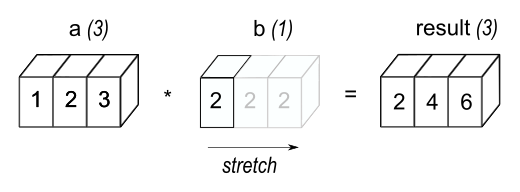

[NumPy user guide -> NumPy fundamentals -> broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html)

In [39]:
a = torch.tensor([[1,2,3],[4,5,6],[7,8,9]])
a_sum = a.sum(dim = 1)
print("不保留dims")
print(a.shape, a_sum.shape)  # torch.Size([3, 3]) torch.Size([3])
print(a_sum)
print(a/a_sum)

print("模拟广播机制得到的 a_sum 计算得到的结果")
# a_sum = a_sum[None, :]
a_sum = torch.tensor([[ 6, 15, 24],
                      [ 6, 15, 24],
                      [ 6, 15, 24]])
# 这里变成了 a的行 对应的和 应该是 a_sum的列， 而不是a_sum的行了
# 这里进行操作就是： [1,2,3]/[6,15,24]  而我们希望的正确操作是: [1,2,3]/[6,6,6](是此时的列了)
print(a/a_sum)

a_sum = a.sum(dim = 1, keepdims=True)  
print("\n保留dims")
print(a.shape, a_sum.shape)  # torch.Size([3, 3]) torch.Size([3, 1])
print(a_sum)
print(a/a_sum)

print("模拟广播机制得到的 a_sum 计算得到的结果")
a_sum = torch.tensor([[ 6,6,6],
                      [15,15,15],
                      [24,24,24]])
# 这里 a的行 在计算时，依然对应 a_sum的行，[1,2,3]和[6,6,6]相除
print(a/a_sum)

# 可以看到，至少对于二维数组来说，不加keepdims，在广播机制计算中，就相当于是转置了

不保留dims
torch.Size([3, 3]) torch.Size([3])
tensor([ 6, 15, 24])
tensor([[0.1667, 0.1333, 0.1250],
        [0.6667, 0.3333, 0.2500],
        [1.1667, 0.5333, 0.3750]])
模拟广播机制得到的 a_sum 计算得到的结果
tensor([[0.1667, 0.1333, 0.1250],
        [0.6667, 0.3333, 0.2500],
        [1.1667, 0.5333, 0.3750]])

保留dims
torch.Size([3, 3]) torch.Size([3, 1])
tensor([[ 6],
        [15],
        [24]])
tensor([[0.1667, 0.3333, 0.5000],
        [0.2667, 0.3333, 0.4000],
        [0.2917, 0.3333, 0.3750]])
模拟广播机制得到的 a_sum 计算得到的结果
tensor([[0.1667, 0.3333, 0.5000],
        [0.2667, 0.3333, 0.4000],
        [0.2917, 0.3333, 0.3750]])


# 神经网络

## 构建数据集

首先需要创建数据集， 输入(x)是`ch1`, 输出(y)是`ch2`

In [66]:
# 数据集就是两个列表， xs是输入， ys是标签/真值， 
# 实际上的每个训练样本就是(x,y)/(stoi[ch1], stoi[ch2])
# 这里只存储 索引序号，不存储对应的字符串，因为训练用的是数字，而不是文字
xs, ys = [], []

for w in words:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        row = stoi[ch1]
        col = stoi[ch2]
        xs.append(row)
        ys.append(col)

# 神经网络的话，需要进一步使用torch转为tensor, 这里并没有指定dtype，但是tensor会自动推导 而Tensor则不会
xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [44]:
len(xs), len(ys), N.sum()

(228146, 228146, tensor(228146))

In [50]:
xs[:5]

tensor([ 0,  5, 13, 13,  1])

## 独热码表示

接下来需要考虑如何把上面这个数据，输入到神经网络中
+ 目前的输入是一堆数字，`tensor([ 0,  5, 13, 13,  1])`
+ 很明显，不能直接把这堆数字逐个作为单独的样本送到网络里
+ **我们希望这个数字只是个索引序号，但是直接送进去，神经网络就只会把这个当成计算的数值**
+ 本质上，这里的`0`和`1`序号，根本没有数字大小值的关系，因此，需要找一种转换方案
  + **对于神经网络来说，最好是可以把单个索引（对应一个字符）转为一个序列的数字，这样就可以和每个神经元的多个w相乘了**

最简单的就是**独热码(one-hot encoding)**

[torch.nn.functional.one_hot](https://docs.pytorch.org/docs/2.12/generated/torch.nn.functional.one_hot.html)
+ `one_hot(tensor, num_classes=-1)`
+ `num_classes (int, optional) – Total number of classes. If set to -1, the number of classes will be inferred as one greater than the largest class value in the input tensor. Default: -1`
+ `num_classes`默认为-1，表示 类别数量会被推理为 比输入tensor中最大类的值大1的结果
+ 即：当输入是 `tensor([ 0,  5, 13, 13,  1])`时，推导的`num_classes = 14`， 即 [0,13]一共14个类

In [61]:
import torch.nn.functional as F
F.one_hot(xs[:5])

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

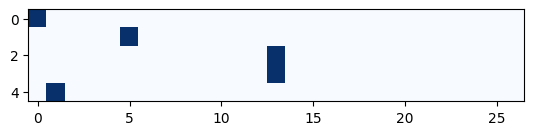

In [63]:
# 这个数据集全部应该是 27个字符 设置 num_classes = 27, 
# `0`对应`.`， 其余`1-26`对应26个字符，最大的index就是26，所以设置-1，自动推导，结果也是27个
xenc = F.one_hot(xs[:5], num_classes = 27)
plt.imshow(xenc, cmap="Blues")
# 可以看到，下图是个5行 27列的数组，除了对应序号的地方编码为1（高亮），其余都是没有被激活的0
# [ 0,  5, 13, 13,  1]

In [64]:
xenc.dtype

torch.int64

根据：`torch.nn.functional.one_hot(tensor, num_classes=-1) → LongTensor`
+ 独热码返回的是一个int64的数据类型（我以为会是布尔值），需要转换一下，转成浮点数，才能送到神经网络里去计算
+ 很明显 `one_hot` 函数里没有`dtype`参数，所以可以理解为 不管输入是什么类型，输出都是 LongTensor 类型
  + 下面这个报错说明，只能接受输入是整数的情况

In [65]:
test = F.one_hot(torch.tensor([1.0, 2.0]))
test.dtype

RuntimeError: one_hot is only applicable to index tensor of type LongTensor.

In [68]:
# 人工转换成float
xenc = F.one_hot(xs[:5], num_classes = 27).float()
xenc, xenc.dtype

(tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0.]]),
 torch.float32)

In [69]:
# import torch.nn.functional as F
# xenc = F.one_hot(xs, num_classes = 27).float()

## 基于torch构建神经网络

In [82]:
# 单个神经元
W = torch.randn((27,1))

print(xenc @ W)
# 矩阵乘法 matmul
# A@B is in fact equal to torch.matmul(A,B) and not matmul(B,A)
# [5,27] @ [27,1] = [5,1] 相当于5个样本经过单个神经元之后，各得到一个数值

# 27个神经元
W = torch.randn((27,27))
print(xenc @ W) 
# [5,27] @ [27,27] = [5,27]  相当于5个样本经过27个神经元之后，各得到27个数值

tensor([[ 0.7294],
        [ 0.8023],
        [-0.0580],
        [-0.0580],
        [ 1.6081]])
tensor([[-0.0314, -0.1785, -1.4982,  0.3605,  0.4942,  2.2400, -0.0584,  0.9185,
         -0.8469, -2.3771,  1.1467,  0.8384,  0.2036,  1.3844, -0.0408,  0.1764,
         -1.3886, -1.1109,  0.7149,  0.5090, -0.3210,  0.9055,  0.0382, -0.0294,
          1.4022, -1.1700,  1.8917],
        [-1.0097, -0.2128, -0.6356,  0.4575,  1.2586, -0.6586, -0.4913,  0.6713,
         -0.4271,  0.6580, -0.8245, -1.6331,  1.2374, -2.0569, -1.2828, -0.6095,
         -0.7297, -0.0856,  1.0674,  0.7709, -0.9430, -0.6889, -0.7351,  0.3782,
         -1.4173,  1.4525,  1.0814],
        [ 1.3295, -2.2487,  1.8467,  0.0517,  1.4466, -2.0192,  0.1162,  0.4577,
         -0.6303,  0.3148,  1.1359, -0.4669, -1.6653, -1.2494,  0.3798,  1.1710,
         -1.1530, -0.7578,  0.6873, -0.1315,  1.4322,  0.0863, -0.2917, -0.4144,
         -0.8509,  0.2871, -0.6081],
        [ 1.3295, -2.2487,  1.8467,  0.0517,  1.4466, -2.0192,  

In [75]:
 (xenc @ W)[3, 13]   
# 这个就表示  第3个样本（从0开始），在第13个神经元（从0开始） 的激活值(激活率)是多少
# 是第3个样本的 27个数字（矩阵乘法里 左边那个矩阵的 第x行） 乘以 W中第13列的27个数字 （矩阵乘法里右边矩阵的第13列）
# 上面 
# 单个神经元维度是 (27,1) 27行，1列；
# 27个神经元维度是 (27,27) 27行，27列；
# 所以列是单个神经元所有w的表示方式，一竖留儿是一个神经元的所有权重

# 所以这里的 W 可以理解为是老师为了讲课，已经提前转置过了

tensor(0.9724)

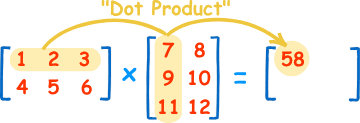

In [74]:
sum(xenc[3,:]*W[:,13]), xenc[3,:].shape, W[:,13].shape

(tensor(0.9724), torch.Size([27]), torch.Size([27]))

## softmax转为概率

**解释**

```bash
[5,27] @ [27,27] = [5,27]  相当于5个样本经过27个神经元之后，各得到27个数值

这里只会使用这一个线性层来作为最简单，最原始的神经网络，也没有激活函数

对于每一个输入样本，我们希望输出的是 关于序列生成下一个字符的概率分布

所以这里 这个线性层的输入是 27（对于27维度的input）， 输出也是 27（对应下一个字符是27个选择里的概率/（生成这27个字符的概率分布））

但是这里的输出 `xenc @ W`的结果，是一群有正有负的小数，不满足概率的定义
1. 一行中所有的列的和不等于1，
2. 有负值（概率应该全都是正数））

在Bigram中，获取N/P概率矩阵时，也在行上，对每个字符进行次数的归一化，变成了概率

这里我们可以把上面的`xenc @ W`的结果视为 `log counts`(对数计数), 
1. 首先要把这些结果全都变成正数， 直接用exp即可. 经过exp后，原本的负数变成了正数，原本的正数变成了更大的正数（很多都会大于1）
    到这里，至少可以作为和 Bigram的N一样的等价物了，如果直接用 (xenc @ W).exp() 作为输出，可以理解为这个神经网络在预测 计数
```

In [85]:
torch.log(torch.tensor([6200,300,10, 2]))

tensor([8.7323, 5.7038, 2.3026, 0.6931])

In [93]:
(xenc @ W).exp()

tensor([[0.9691, 0.8365, 0.2235, 1.4340, 1.6392, 9.3932, 0.9433, 2.5056, 0.4288,
         0.0928, 3.1477, 2.3126, 1.2259, 3.9924, 0.9600, 1.1930, 0.2494, 0.3293,
         2.0440, 1.6636, 0.7254, 2.4731, 1.0390, 0.9710, 4.0641, 0.3104, 6.6310],
        [0.3643, 0.8083, 0.5296, 1.5802, 3.5206, 0.5176, 0.6118, 1.9568, 0.6524,
         1.9309, 0.4384, 0.1953, 3.4467, 0.1279, 0.2773, 0.5436, 0.4821, 0.9179,
         2.9079, 2.1618, 0.3895, 0.5021, 0.4795, 1.4596, 0.2424, 4.2738, 2.9487],
        [3.7793, 0.1055, 6.3388, 1.0531, 4.2485, 0.1328, 1.1232, 1.5804, 0.5324,
         1.3700, 3.1140, 0.6269, 0.1891, 0.2867, 1.4620, 3.2252, 0.3157, 0.4687,
         1.9883, 0.8768, 4.1880, 1.0901, 0.7470, 0.6607, 0.4270, 1.3326, 0.5444],
        [3.7793, 0.1055, 6.3388, 1.0531, 4.2485, 0.1328, 1.1232, 1.5804, 0.5324,
         1.3700, 3.1140, 0.6269, 0.1891, 0.2867, 1.4620, 3.2252, 0.3157, 0.4687,
         1.9883, 0.8768, 4.1880, 1.0901, 0.7470, 0.6607, 0.4270, 1.3326, 0.5444],
        [0.3842, 1.8114,

C:\Users\shanhuang\AppData\Local\Temp\ipykernel_10608\1709184590.py:3: RuntimeWarning: invalid value encountered in log
  y2 = np.log(x)


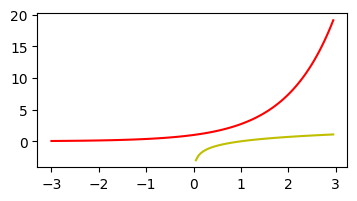

In [92]:
x = np.arange(-3,3,0.05)
y1 = np.exp(x)
y2 = np.log(x)
plt.figure(figsize=(4,2))
plt.plot(x,y1,'r-')
plt.plot(x,y2,'y-')

In [102]:
logits = xenc @ W   # log-counts
counts = logits.exp() # equivalent to N(Bigram)
probs = counts/counts.sum(dim=1, keepdims = True)   # [5,27] 一行是一个样本的27个概率，所以是这行的27列求和
probs, sum(probs[0])

(tensor([[0.0187, 0.0161, 0.0043, 0.0277, 0.0316, 0.1813, 0.0182, 0.0484, 0.0083,
          0.0018, 0.0608, 0.0446, 0.0237, 0.0771, 0.0185, 0.0230, 0.0048, 0.0064,
          0.0395, 0.0321, 0.0140, 0.0477, 0.0201, 0.0187, 0.0785, 0.0060, 0.1280],
         [0.0106, 0.0236, 0.0155, 0.0461, 0.1027, 0.0151, 0.0179, 0.0571, 0.0190,
          0.0563, 0.0128, 0.0057, 0.1006, 0.0037, 0.0081, 0.0159, 0.0141, 0.0268,
          0.0849, 0.0631, 0.0114, 0.0147, 0.0140, 0.0426, 0.0071, 0.1247, 0.0861],
         [0.0904, 0.0025, 0.1516, 0.0252, 0.1016, 0.0032, 0.0269, 0.0378, 0.0127,
          0.0328, 0.0745, 0.0150, 0.0045, 0.0069, 0.0350, 0.0771, 0.0076, 0.0112,
          0.0476, 0.0210, 0.1002, 0.0261, 0.0179, 0.0158, 0.0102, 0.0319, 0.0130],
         [0.0904, 0.0025, 0.1516, 0.0252, 0.1016, 0.0032, 0.0269, 0.0378, 0.0127,
          0.0328, 0.0745, 0.0150, 0.0045, 0.0069, 0.0350, 0.0771, 0.0076, 0.0112,
          0.0476, 0.0210, 0.1002, 0.0261, 0.0179, 0.0158, 0.0102, 0.0319, 0.0130],
         [0.

[torch.nn.functional.softmax](https://docs.pytorch.org/docs/2.12/generated/torch.nn.functional.softmax.html)

In [105]:
probs = F.softmax(logits,dim = 1)
probs, sum(probs[0])

(tensor([[0.0187, 0.0161, 0.0043, 0.0277, 0.0316, 0.1813, 0.0182, 0.0484, 0.0083,
          0.0018, 0.0608, 0.0446, 0.0237, 0.0771, 0.0185, 0.0230, 0.0048, 0.0064,
          0.0395, 0.0321, 0.0140, 0.0477, 0.0201, 0.0187, 0.0785, 0.0060, 0.1280],
         [0.0106, 0.0236, 0.0155, 0.0461, 0.1027, 0.0151, 0.0179, 0.0571, 0.0190,
          0.0563, 0.0128, 0.0057, 0.1006, 0.0037, 0.0081, 0.0159, 0.0141, 0.0268,
          0.0849, 0.0631, 0.0114, 0.0147, 0.0140, 0.0426, 0.0071, 0.1247, 0.0861],
         [0.0904, 0.0025, 0.1516, 0.0252, 0.1016, 0.0032, 0.0269, 0.0378, 0.0127,
          0.0328, 0.0745, 0.0150, 0.0045, 0.0069, 0.0350, 0.0771, 0.0076, 0.0112,
          0.0476, 0.0210, 0.1002, 0.0261, 0.0179, 0.0158, 0.0102, 0.0319, 0.0130],
         [0.0904, 0.0025, 0.1516, 0.0252, 0.1016, 0.0032, 0.0269, 0.0378, 0.0127,
          0.0328, 0.0745, 0.0150, 0.0045, 0.0069, 0.0350, 0.0771, 0.0076, 0.0112,
          0.0476, 0.0210, 0.1002, 0.0261, 0.0179, 0.0158, 0.0102, 0.0319, 0.0130],
         [0.

## 开始优化

之前所有的内容，整合起来

In [109]:
import torch.nn.functional as F
g = torch.Generator().manual_seed(2147483647+1)

# 1. 构建数据集
xs, ys = [], []

for w in words:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        row = stoi[ch1]
        col = stoi[ch2]
        xs.append(row)
        ys.append(col)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

# 2. 构建网络(以下操作全都是可微分的)
W = torch.randn((27,27), generator = g)

xenc = F.one_hot(xs, num_classes = 27).float() # one-hot encoding
logits = xenc @ W   # predict log-counts (预测的对数计数结果)

counts = logits.exp() # fake counts,equivalent to N(Bigram)
probs = counts/counts.sum(dim=1, keepdims = True) # probabilities for next charater
# probs = F.softmax(logits,dim = 1) # btw(by the way) 最后两行的实现等价于 softmax

In [110]:
# ✅直观感受下损失函数
nlls= torch.zeros(5)
for i in range(5):
    # .emma. 这个单词的所有bigram项是5个
    x = xs[i].item()
    y = ys[i].item()
    print("-"*20)
    print(f"Bigram example [{i+1}]: {itos[x]}{itos[y]} (indexes: {x}, {y})")
    print(f"input to the neural net: {x}")
    print(f"output probabilities from the neural net: {probs[i]}")
    print(f"label(actual next charater): {y}")
    p = probs[i,y]
    print(f"probabilities assigned by the net to the correct character: {p}")
    logp = torch.log(p)
    print(f"log likelihood: {logp.item()}")
    nll = -logp
    print(f"negative log likelihood: {nll.item()}")
    nlls[i] = nll
print("="*20)
print(f"average negative log likelihood, i.e. loss = {nlls.mean().item()}")

--------------------
Bigram example [1]: .e (indexes: 0, 5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0049, 0.0959, 0.0281, 0.0703, 0.0961, 0.0573, 0.0241, 0.0135, 0.0093,
        0.1416, 0.0225, 0.0217, 0.0513, 0.0106, 0.0097, 0.0291, 0.0229, 0.0273,
        0.0325, 0.0275, 0.0446, 0.0501, 0.0214, 0.0093, 0.0120, 0.0354, 0.0310])
label(actual next charater): 5
probabilities assigned by the net to the correct character: 0.05734505504369736
log likelihood: -2.858668565750122
negative log likelihood: 2.858668565750122
--------------------
Bigram example [2]: em (indexes: 5, 13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0426, 0.0113, 0.0266, 0.0507, 0.2370, 0.0580, 0.0421, 0.0094, 0.0136,
        0.0297, 0.0044, 0.0782, 0.1028, 0.0146, 0.0172, 0.0288, 0.0263, 0.0319,
        0.0248, 0.0210, 0.0063, 0.0057, 0.0309, 0.0269, 0.0298, 0.0089, 0.0205])
label(actual next charater): 13
probabilities assigned by the net to t

```bash
g的种子 = 2147483647 时，loss = 4.543462753295898
g的种子 = 2147483647+1 时，loss =  3.377087831497192

邪修——随机数种子大法

不是正道，优化神经网络的正道：从一个随机猜测开始，坚持在这个基础上优化，即便它一开始表现不好~
```

In [111]:
ys[:5], probs[:5,:].shape

(tensor([ 5, 13, 13,  1,  0]), torch.Size([5, 27]))

In [112]:
# 实际上，我们只关注 每个样本里 正确的y对应的概率，即：
# 对于上面五个样本，第1个样本，关注index5；第2个样本，关注index13；...
probs[0,5], probs[1,13], probs[2,13], probs[3,1], probs[4,1]

(tensor(0.0573),
 tensor(0.0146),
 tensor(0.0321),
 tensor(0.0235),
 tensor(0.0209))

In [113]:
probs[torch.arange(5),ys[:5]]  # 这种索引方式更便捷

tensor([0.0573, 0.0146, 0.0321, 0.0235, 0.0737])

In [ ]:
# 3. 用nll作为损失函数 负似然（平均）对数开始进行反向传播

## torch.tensor VS. torch.Tensor

+ [torch.Tensor](https://docs.pytorch.org/docs/2.12/tensors.html)
+ [torch.tensor](https://docs.pytorch.org/docs/2.12/generated/torch.tensor.html)
  + `Constructs a tensor with no autograd history (also known as a “leaf tensor”, see Autograd mechanics) by copying data.`
+ [pytorch -> torch/_tensor.py](https://github.com/pytorch/pytorch/blob/main/torch/_tensor.py)
+ [What is the difference between torch.tensor and torch.Tensor?](https://stackoverflow.com/questions/51911749/what-is-the-difference-between-torch-tensor-and-torch-tensor)
    > torch.tensor infers the dtype automatically, while torch.Tensor returns a torch.FloatTensor. I would recommend to stick to torch.tensor, which also has arguments like dtype, if you would like to change the type.

二者的主要区别：
1. `torch.tensor`会自动推导数据类型，而`torch.Tensor`默认返回`torch.FloatTensor`
2. 在pytorch中，`torch.Tensor`是最主要的类，其余所有的tensors都是`torch.Tensor`的实例(instances)
   ```bash
       torch.tensor(data, *, dtype=None, device=None, requires_grad=False, pin_memory=False) → Tensor
    # torch.tensor的函数定义，返回的是一个torch.Tensor对象
   ```
   + 当直接调用`torch.Tensor()`, 会得到一个没有data的空tensor
   + 但是直接调用 `torch.tensor()`就会报错

In [51]:
a = torch.tensor([1,2,3])
a.dtype

torch.int64

In [52]:
a = torch.Tensor([1,2,3])
a.dtype

torch.float32

In [53]:
torch.Tensor()

tensor([])

```python
torch.tensor()
```

```bash
---------------------------------------------------------------------------
TypeError                                 Traceback (most recent call last)
Cell In[48], line 1
----> 1 torch.tensor()

TypeError: tensor() missing 1 required positional arguments: "data"
```

## 矩阵乘法 @

当 `@` 出现在两个对象之间时（例如 `A @ B`），它表示矩阵乘法。这是在 Python 3.5 中引入的，主要为了方便 NumPy 等科学计算库进行矩阵运算。

如果重载该运算符，对应的魔术方法（重载函数）名称如下：
+ `__matmul__(self, other)`：对应 `self @ other`。
+ `__rmatmul__(self, other)`：对应 `other @ self`。当左操作数没有实现 `__matmul__` 时，Python 会尝试调用右操作数的这个方法（反射机制）。
+ `__imatmul__(self, other)`：对应 `self @= other`（就地矩阵乘法赋值）。